In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('base_aed_evasao_com_estado_civil.xlsx')

In [193]:
print(df.shape)
print()
print(df.info())
print()
df.head()

(150, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Idade                   150 non-null    int64  
 1   Gênero                  150 non-null    object 
 2   Estado Civil            150 non-null    object 
 3   Renda Familiar (R$)     150 non-null    float64
 4   Escola Ensino Médio     150 non-null    object 
 5   Status                  150 non-null    object 
 6   Motivo da Evasão        54 non-null     object 
 7   Trabalha Atualmente     150 non-null    object 
 8   Último Período Cursado  150 non-null    int64  
 9   Desempenho              150 non-null    float64
 10  Trabalha_Num            150 non-null    int64  
 11  Evadido_Num             150 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 14.2+ KB
None



,Idade,Gênero,Estado Civil,Renda Familiar (R$),Escola Ensino Médio,Status,Motivo da Evasão,Trabalha Atualmente,Último Período Cursado,Desempenho,Trabalha_Num,Evadido_Num
0,18,Feminino,Solteiro(a),1414.37,Pública,Ativo,NaN,Não,5,68.5,0,0
1,20,Masculino,Divorciado(a),4238.37,Privada,Evadido,Dificuldade financeira,Não,6,76.4,0,1
2,18,Masculino,Viúvo(a),2295.80,Pública,Ativo,NaN,Não,9,77.8,0,0
3,27,Outro,Solteiro(a),3765.94,Pública,Evadido,Baixo desempenho,Sim,1,61.9,1,1
4,30,Masculino,Casado(a),3991.39,Privada,Ativo,NaN,Sim,1,61.6,1,0


## 3.1 Existe uma faixa etária predominante entre os evadidos?

Média: 24.11
Moda: 20
Mediana: 24.0
Variância: 26.55


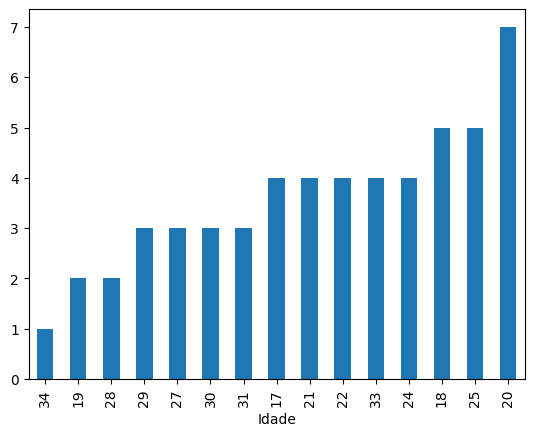

In [192]:
df_evasao_por_idade = df[df['Status'] == 'Evadido'].groupby('Idade').size().sort_values()

idades_evadidas = df[df['Status'] == 'Evadido']['Idade']

print(f'Média: {idades_evadidas.mean():.2f}')
print(f'Moda: {idades_evadidas.mode()[0]}')
print(f'Mediana: {idades_evadidas.median()}')
print(f'Variância: {idades_evadidas.var():.2f}')


plot1 = df_evasao_por_idade.plot(kind = 'bar')
plot1;

## 3.2 Estudantes que trabalham têm maior probabilidade de evadir?

Covariância: -0.03

Quantidade de alunos:

Status               Evadido
Trabalha Atualmente         
Não                       31
Sim                       23

Taxa de alunos por status:

Status               Ativo  Evadido  Formado
Trabalha Atualmente                         
Não                  42.67    41.33    16.00
Sim                  44.00    30.67    25.33


<Axes: xlabel='Trabalha Atualmente'>

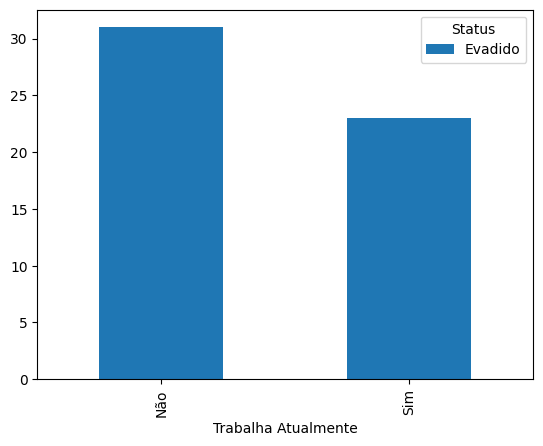

In [258]:
df['Trabalha_Num'] = (df['Trabalha Atualmente'] == 'Sim').astype(int)
df['Evadido_Num'] = (df['Status'] == 'Evadido').astype(int)

covariancia = df['Trabalha_Num'].cov(df['Evadido_Num'])

print(f'Covariância: {covariancia:.2f}')

print()
print('Quantidade de alunos:')
print()
df_evadidos = df[df['Status'] == 'Evadido']
tabela_cruzada = pd.crosstab(df_evadidos['Trabalha Atualmente'], df_evadidos['Status'])
print(tabela_cruzada)


print()
print('Taxa de alunos por status:')
print()
percentuais = pd.crosstab(df['Trabalha Atualmente'], df['Status'], normalize='index') * 100
print(percentuais.round(2))


tabela_cruzada.plot(kind = 'bar')

## 3.3 A renda influencia na evasão?

In [272]:
renda_media = df.groupby('Status')['Renda Familiar (R$)'].mean().round(2)
renda_media
df['Evadido'] = (df['Status'] == 'Evadido').astype(int)


evadidos = df[df['Status'] == 'Evadido']['Renda Familiar (R$)']

print('\nRenda Evadidos:')
print(f"Média:    R$ {evadidos.mean():.2f}")
print(f"Mediana:  R$ {evadidos.median():.2f}")
print(f"Moda:     R$ {evadidos.mode()[0]:.2f}" if len(evadidos.mode()) > 0 else "Moda: Sem repetição")


nao_evadidos = df[df['Status'] != 'Evadido']['Renda Familiar (R$)']

print("\nRenda Não Evadidos:")
print(f"Média:    R$ {nao_evadidos.mean():.2f}")
print(f"Mediana:  R$ {nao_evadidos.median():.2f}")
print(f"Moda:     R$ {nao_evadidos.mode()[0]:.2f}" if len(nao_evadidos.mode()) > 0 else "Moda: Sem repetição")

print("\nDIFERENÇAS")
print(f"Diferença de Média:   R$ {evadidos.mean() - nao_evadidos.mean():.2f}")
print(f"Diferença de Mediana: R$ {evadidos.median() - nao_evadidos.median():.2f}")

print("\nVARIÂNCIA")
print(f"Evadidos:      {evadidos.var():.2f}")
print(f"Não Evadidos:  {nao_evadidos.var():.2f}")

print("\nDESVIO PADRÃO")
print(f"Evadidos:      R$ {evadidos.std():.2f}")
print(f"Não Evadidos:  R$ {nao_evadidos.std():.2f}")

covariancia = df['Renda Familiar (R$)'].cov(df['Evadido'])
correlacao = df['Renda Familiar (R$)'].corr(df['Evadido'])

print(f"\nCovariância: {covariancia:.2f}\nCorrelação: {correlacao.__round__(2)}")


Renda Evadidos:
Média:    R$ 2488.89
Mediana:  R$ 2445.96
Moda:     R$ 846.30

Renda Não Evadidos:
Média:    R$ 2605.71
Mediana:  R$ 2495.44
Moda:     R$ 500.00

DIFERENÇAS
Diferença de Média:   R$ -116.82
Diferença de Mediana: R$ -49.48

VARIÂNCIA
Evadidos:      942161.94
Não Evadidos:  1097979.43

DESVIO PADRÃO
Evadidos:      R$ 970.65
Não Evadidos:  R$ 1047.85

Covariância: -27.10
Correlação: -0.06


## 3.4 Qual período do curso tem maior taxa de evasão?

In [273]:
tabela_periodo = pd.crosstab(df['Último Período Cursado'], df['Status'], normalize = 'index') * 100

periodo_maior = tabela_periodo['Evadido'].idxmax()
taxa_periodo_maior = tabela_periodo['Evadido'].max()


print(tabela_periodo)
print()
print(f'O período com maior taxa de evasão é o {periodo_maior}, com {taxa_periodo_maior:.2f}%')

Status                      Ativo    Evadido    Formado
Último Período Cursado                                 
1                       44.444444  27.777778  27.777778
2                       41.176471  23.529412  35.294118
3                       77.777778   0.000000  22.222222
4                       41.176471  35.294118  23.529412
5                       28.571429  71.428571   0.000000
6                       52.631579  47.368421   0.000000
7                       46.153846  38.461538  15.384615
8                       53.333333  40.000000   6.666667
9                       29.166667  33.333333  37.500000
10                      27.272727  54.545455  18.181818

O período com maior taxa de evasão é o 5, com 71.43%


## 3.5 Qual o maior motivo de evasão?

In [279]:
motivo_evasao = df[df['Status'] == 'Evadido']['Motivo da Evasão'].value_counts()
motivo_evasao

Motivo da Evasão
Baixo desempenho          18
Trabalho                  11
Dificuldade financeira    10
Motivos pessoais           8
Mudança de curso           7
Name: count, dtype: int64

## 3.6 O desempenho tem alguma relação com a evasão?

In [ ]:
desempenho_evasao = df[['Status', 'Desempenho']]
desempenho_evasao

evadidos = df[df['Status'] == 'Evadido']['Desempenho']

print('\nDesempenho Evadidos:')
print(f"Média:     {evadidos.mean():.2f}")
print(f"Mediana:   {evadidos.median():.2f}")
print(f"Moda:      {evadidos.mode()[0]:.2f}" if len(evadidos.mode()) > 0 else "Moda: Sem repetição")


nao_evadidos = df[df['Status'] != 'Evadido']['Desempenho']

print("\nDesempenho Não Evadidos:")
print(f"Média:     {nao_evadidos.mean():.2f}")
print(f"Mediana:   {nao_evadidos.median():.2f}")
print(f"Moda:      {nao_evadidos.mode()[0]:.2f}" if len(nao_evadidos.mode()) > 0 else "Moda: Sem repetição")

print("\nDIFERENÇAS")
print(f"Diferença de Média:    {evadidos.mean() - nao_evadidos.mean():.2f}")
print(f"Diferença de Mediana:  {evadidos.median() - nao_evadidos.median():.2f}")

print("\nVARIÂNCIA")
print(f"Evadidos:      {evadidos.var():.2f}")
print(f"Não Evadidos:  {nao_evadidos.var():.2f}")

print("\nDESVIO PADRÃO")
print(f"Evadidos:       {evadidos.std():.2f}")
print(f"Não Evadidos:   {nao_evadidos.std():.2f}")

covariancia = df['Desempenho'].cov(df['Evadido'])
correlacao = df['Desempenho'].corr(df['Evadido'])

print(f"\nCovariância: {covariancia:.2f}\nCorrelação: {correlacao.__round__(2)}")


Desempenho Evadidos:
Média:     74.02
Mediana:   73.20
Moda:      72.40

Desempenho Não Evadidos:
Média:     71.71
Mediana:   70.65
Moda:      61.70

DIFERENÇAS
Diferença de Média:    2.31
Diferença de Mediana:  2.55

VARIÂNCIA
Evadidos:      53.02
Não Evadidos:  53.40

DESVIO PADRÃO
Evadidos:       7.28
Não Evadidos:   7.31

Covariância: 0.53
Correlação: 0.15
